# Customer Lifetime Value Prediction

This project predicts customer lifetime value (CLTV) for UK customers using BG-NBD and Gamm-Gamma models.

The objective is to estimate future customer value, compare different time horizons, and generate customer segments for business decision-making.

## 1 - Business Problem

A UK-based retail company wants to create a roadmap for its sales and marketing activities.

To support medium- and long-term planning, the company needs to estimate the future value of existing customers.

This project focuses on:
- predicting 6-month CLTV
- comparing 1-month and 12-month CLTV
- segmenting customers based on 6-month CLTV
- generating business recommendations

## 2 - Import and Notebooks Settings


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data_prep import load_data,initial_check,prepare_retail_data
from src.cltv_builder import create_cltv_df,fit_bgf,fit_ggf,calculate_cltv
from src.segmentation import create_cltv_segments,segment_summary

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: "%.2f" % x)


## 3 - Load Dataset

In [2]:
data_path = Path.cwd().parent / "data" / "raw" / "online_retail_II.xlsx"

if not data_path.exists():
    data_path = Path.cwd().parent / "data" / "raw" / "online_retail.xlsx"

df = load_data(data_path)
print(f"Loading dataset: {data_path.name}")
print(f"Dataset shape: {df.shape}")
df.head()

Loading dataset: online_retail_II.xlsx
Dataset shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


## 4 - Initial Data Check

In [3]:
initial_check(df)

Shape: (541910, 8)

Types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Head:
   Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   2.55     17850.00  United Kingdom
1  536365     71053                  WHITE METAL LANTERN         6 2010-12-01 08:26:00   3.39     17850.00  United Kingdom
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00   2.75     17850.00  United Kingdom
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00   3.39     17850.00  United Kingdom
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00   3.39  

## 5 - Data Preparation

In [4]:
df_clean = prepare_retail_data(df)

print(f"Original Shape: {df.shape}")
print(f"Prepared Shape: {df_clean.shape}")
print("\nMissin values after preparation:")
print(df_clean.isnull().sum())

df_clean.head()

Original Shape: (541910, 8)
Prepared Shape: (397885, 9)

Missin values after preparation:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34


## 6 - Create CLTV Modeling Table

In [5]:
cltv_df = create_cltv_df(df_clean, country="United Kingdom")
cltv_df.head()


,Customer ID,recency,T,frequency,monetary
1,12747.00,52.29,52.86,11,381.46
2,12748.00,53.14,53.57,209,161.34
3,12749.00,29.86,30.57,5,818.18
4,12820.00,46.14,46.86,4,235.59
6,12822.00,2.29,12.57,2,474.44


## 7 - Check CLTV Modeling Table

In [6]:
print(cltv_df.shape)
print(cltv_df.isnull().sum())
cltv_df.describe().T

(2570, 5)
Customer ID    0
recency        0
T              0
frequency      0
monetary       0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Customer ID,2570.00,15553.69,1576.37,12747.00,14206.00,15575.50,16926.25,18287.00
recency,2570.00,28.55,16.24,0.00,14.43,29.86,42.71,53.29
T,2570.00,37.15,14.75,0.57,28.29,40.57,51.29,53.57
frequency,2570.00,5.95,8.40,2.00,2.00,4.00,6.00,209.00
monetary,2570.00,397.18,1726.04,3.45,189.58,294.27,421.26,84236.25


## 8 - Fit BG-NBD Model

In [7]:
bgf = fit_bgf(cltv_df)
bgf

<lifetimes.BetaGeoFitter: fitted with 2570 subjects, a: 0.12, alpha: 11.69, b: 2.52, r: 2.22>

### Expected Purchase for 6-Month

In [8]:
cltv_df["expected_purc_6_month"] = bgf.predict(
    24,
    cltv_df["frequency"],
    cltv_df["recency"],
    cltv_df["T"]
)

cltv_df[["Customer ID", "frequency", "recency","T","expected_purc_6_month"]].head()

,Customer ID,frequency,recency,T,expected_purc_6_month
1,12747.00,11,52.29,52.86,4.76
2,12748.00,209,53.14,53.57,76.00
3,12749.00,5,29.86,30.57,3.89
4,12820.00,4,46.14,46.86,2.43
6,12822.00,2,2.29,12.57,2.95


## 9 - Fit Gamma-Gamma Model

In [9]:
ggf = fit_ggf(cltv_df)
ggf

<lifetimes.GammaGammaFitter: fitted with 2570 subjects, p: 3.81, q: 0.34, v: 3.74>

### Expected Average Profit

In [10]:
cltv_df["expected_average_profit"] = ggf.conditional_expected_average_profit(
    cltv_df["frequency"],
    cltv_df["monetary"]
)

cltv_df[["Customer ID", "monetary", "expected_average_profit"]].head()

,Customer ID,monetary,expected_average_profit
1,12747.00,381.46,387.87
2,12748.00,161.34,161.49
3,12749.00,818.18,848.13
4,12820.00,235.59,247.16
6,12822.00,474.44,521.17


## 10 - 6-Month CLTV Prediction

In [11]:
cltv_6m = calculate_cltv(cltv_df,bgf,ggf,month=6)
cltv_6m.sort_values("clv", ascending=False).head(10)

,Customer ID,recency,T,frequency,monetary,expected_purc_6_month,expected_average_profit,clv
2598,16446.00,29.14,29.57,2,84236.25,2.29,92172.27,221321.52
3783,18102.00,52.29,52.57,60,4327.62,22.72,4340.14,103321.64
3314,17450.00,51.29,52.71,46,4229.36,17.48,4245.33,77774.65
902,14096.00,13.86,14.71,17,3833.22,16.53,3872.66,66983.28
2270,16000.00,0.00,0.57,3,4131.23,9.11,4384.07,41743.30
3356,17511.00,52.86,53.57,31,2937.50,11.91,2954.02,36874.45
2766,16684.00,50.43,51.29,28,2380.48,11.21,2395.35,28144.13
620,13694.00,52.71,53.57,50,1300.79,18.74,1305.36,25635.35
897,14088.00,44.57,46.14,13,3883.99,6.10,3936.40,25150.15
1771,15311.00,53.29,53.57,91,667.78,33.55,669.09,23521.78


## 11 - 1-Month vs 12-Month CLTV Comparison

In [12]:
cltv_1m = calculate_cltv(cltv_df,bgf,ggf,month=1)
cltv_12m = calculate_cltv(cltv_df,bgf,ggf,month=12)

In [13]:
top_10_1m = cltv_1m.sort_values("clv", ascending=False).head(10)
top_10_12m = cltv_12m.sort_values("clv", ascending=False).head(10)

top_10_1m[["Customer ID", "clv"]]

,Customer ID,clv
2598,16446.00,38867.09
3783,18102.00,17959.41
3314,17450.00,13518.91
902,14096.00,11865.75
2270,16000.00,7601.98
3356,17511.00,6408.81
2766,16684.00,4894.25
620,13694.00,4455.03
897,14088.00,4380.81
1771,15311.00,4087.44


In [14]:
top_10_12m[["Customer ID", "clv"]]

,Customer ID,clv
2598,16446.00,419387.39
3783,18102.00,197303.72
3314,17450.00,148518.18
902,14096.00,126232.00
2270,16000.00,77567.49
3356,17511.00,70422.11
2766,16684.00,53724.43
620,13694.00,48961.60
897,14088.00,47946.17
1771,15311.00,44927.48


In [15]:
comparison_df = top_10_1m[["Customer ID", "clv"]].rename(columns={"clv": "clv_1m"}).merge(
    top_10_12m[["Customer ID", "clv"]].rename(columns={"clv": "clv_12m"}),
    on="Customer ID",
    how="outer"
)

comparison_df

,Customer ID,clv_1m,clv_12m
0,13694.00,4455.03,48961.60
1,14088.00,4380.81,47946.17
2,14096.00,11865.75,126232.00
3,15311.00,4087.44,44927.48
4,16000.00,7601.98,77567.49
5,16446.00,38867.09,419387.39
6,16684.00,4894.25,53724.43
7,17450.00,13518.91,148518.18
8,17511.00,6408.81,70422.11
9,18102.00,17959.41,197303.72


## 12 - CLTV Segmentation

In [16]:
cltv_6m = create_cltv_segments(cltv_6m)
cltv_6m["segment"].value_counts()

segment
D    643
A    643
C    642
B    642
Name: count, dtype: int64

In [17]:
segment_df = segment_summary(cltv_6m)
segment_df

,segment,customer_count,avg_clv,avg_frequency,avg_monetary
0,D,643,274.80,3.00,181.92
1,C,642,720.13,4.10,263.10
2,B,642,1285.31,5.44,356.65
3,A,643,4425.63,11.27,786.80


## 13 - Visualizations

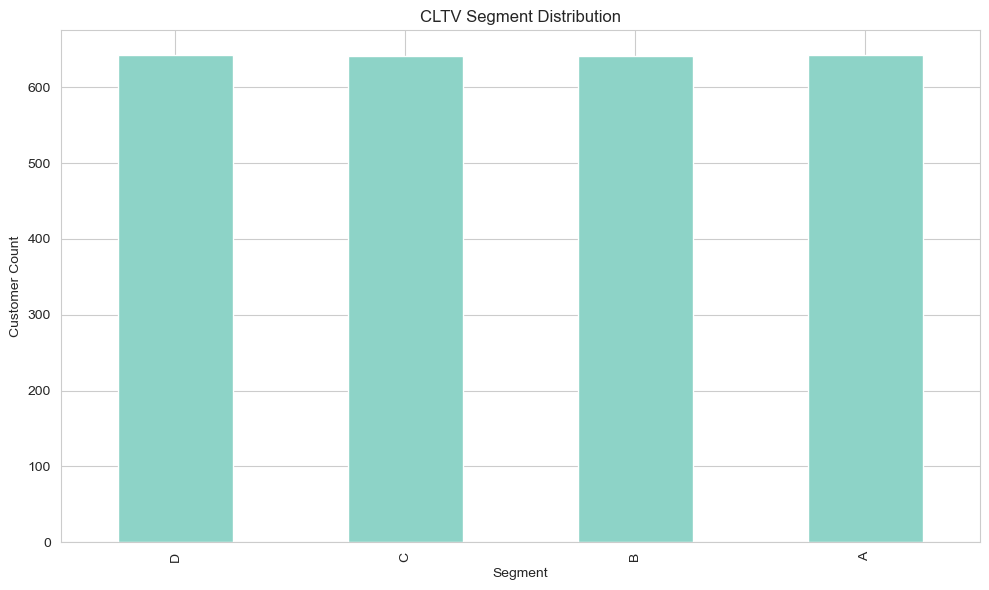

In [18]:
plt.figure(figsize=(10,6))
cltv_6m["segment"].value_counts().sort_index().plot(kind="bar")
plt.title("CLTV Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig("../images/cltv_segment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

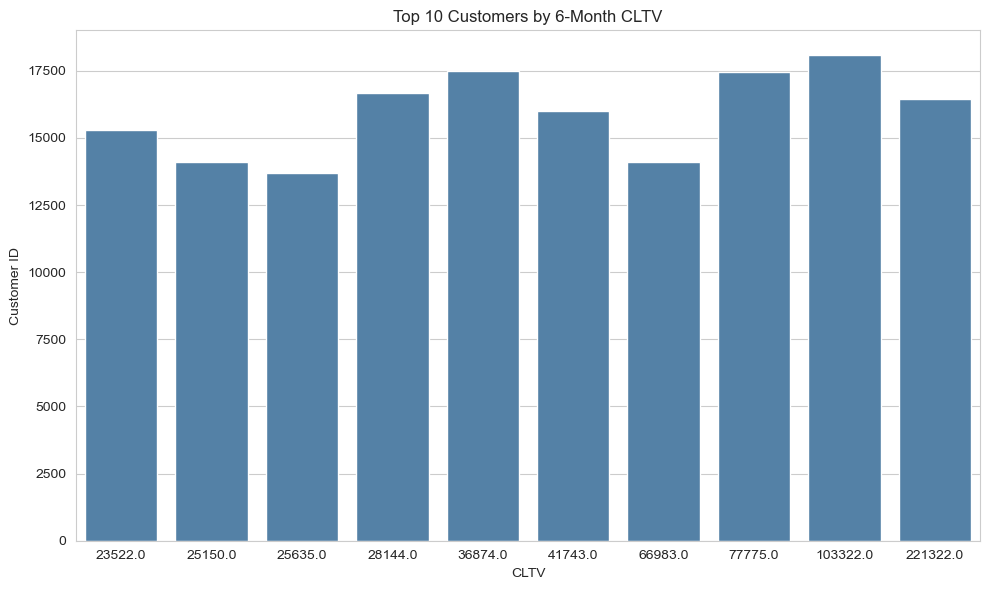

In [20]:

top10_6m = cltv_6m.sort_values("clv", ascending=False).head(10)
top10_6m["clv"] = top10_6m["clv"].round(0)

plt.figure(figsize=(10,6))
sns.barplot(data=top10_6m, x="clv", y="Customer ID", color="steelblue")
plt.title("Top 10 Customers by 6-Month CLTV")
plt.xlabel("CLTV")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("../images/top10_cltv_6m.png", dpi=300, bbox_inches="tight")
plt.show()

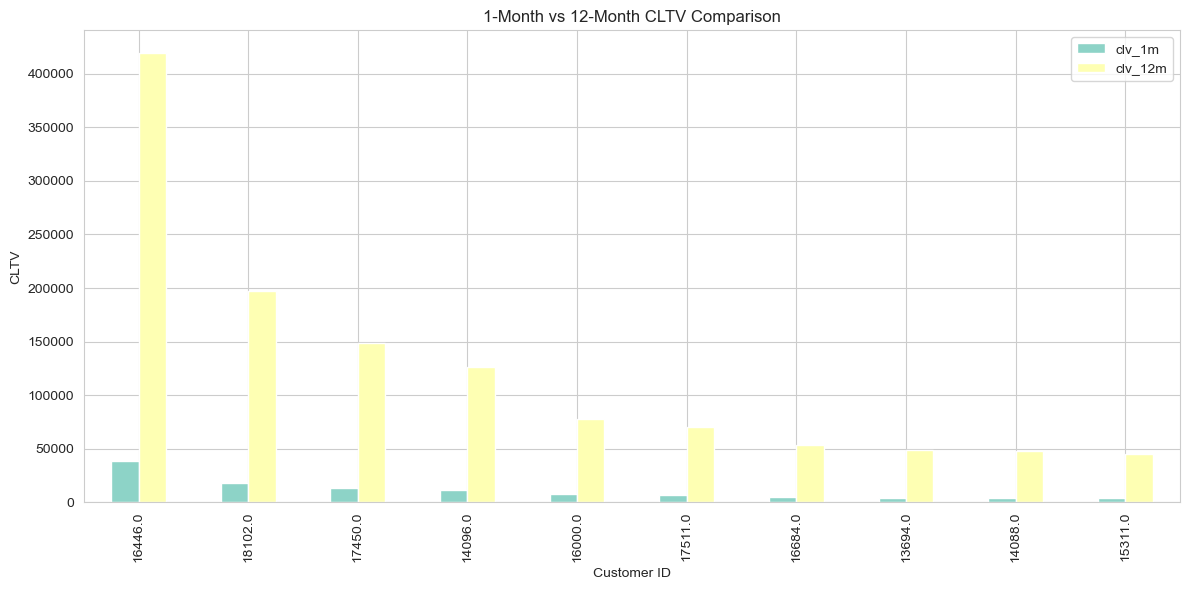

In [22]:
comparison_plot = comparison_df.fillna(0).copy()
comparison_plot = comparison_plot.sort_values("clv_12m", ascending=False)

comparison_plot.set_index("Customer ID")[["clv_1m","clv_12m"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("1-Month vs 12-Month CLTV Comparison")
plt.xlabel("Customer ID")
plt.ylabel("CLTV")
plt.tight_layout()
plt.savefig("../images/comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 14 - Business Insights and Recommendations

### 6-Month CLTV Insights
Customers with high CLTV tend to have higher purchase frequency and higher average monetary value.

### 1-Month vs 12-Month Difference
Short-term CLTV highlights recently active customers, while long-term CLTV gives more weight to repeat purchasing behavior and sustained profitability

### Recommendations
- Segment A customers should be prioritized with VIP campaigns and premium offers.
- Lower-value segments can be targeted with reactivation campings and personalized discounts.

## 15 - Export Outputs

In [23]:
cltv_6m.to_csv("../data/processed/cltv_6m.csv", index=False)
comparison_df.to_csv("../data/processed/cltv_1m_vs_cltv_12m.csv", index=False)
segment_df.to_csv("../data/processed/cltv_segment_summary.csv", index=False)